In [4]:
%load_ext autoreload
%autoreload 2

In [2]:

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 导入包内模块
from geovisxrd.modeling.trainer import train_model
from geovisxrd.modeling.save import save_model
from geovisxrd.explaining.explainer import shapexplainer
from geovisxrd.explaining.io import save_shap_results, load_shap_results
from geovisxrd.explaining.visualization import plot_all_shap_charts
from geovisxrd.causal.discovery import get_causal_model
from geovisxrd.threshold.optimizer import analyze_threshold_stability
from geovisxrd.plotting.plotting import plot_causal_graph_networkx
from geovisxrd.plotting.plotting import plot_dependence_2d_lowess, plot_dependence_3d_interaction, plot_pos_neg_ratio

    

/Users/shumouren/miniconda3/envs/camp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
X = data.data.iloc[:500, :]  # 取前 500 条样本以加快测试速度
y = data.target.iloc[:500]

print(f"✅ 数据加载完成。特征: {list(X.columns)}")

✅ 数据加载完成。特征: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [9]:
output_dirs = ["test_outputs/models", "test_outputs/shap", "test_outputs/causal/model", "test_outputs/stability",
               "test_outputs/causal/optimized","test_outputs/causal/pictures"]
for d in output_dirs:
    os.makedirs(d, exist_ok=True)

In [8]:
# 1. 定义每个回归模型独有的参数配置
model_configs = {
    "rf": {
        "params": {"n_estimators": 100, "max_depth": 10, "random_state": 42}
    },
    "xgb": {
        "params": {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 6}
    },
    "lgb": {
        "params": {"n_estimators": 150, "num_leaves": 31, "learning_rate": 0.1}
    },
    "mlp": {
        "params": {"hidden_layer_sizes": (64, 32), "max_iter": 500, "random_state": 1}
    },
    "linear": {
        "params": {} # 线性回归通常不需要额外参数
    }
}

results_summary = []

for m_name, config in model_configs.items():
    print(f"\n" + "="*50)
    print(f"🔎 正在测试模型: {m_name.upper()}")
    
    try:
        # 1. 训练模型 - 解包 config['params'] 传入特定超参数
        # train_model 会调用 get_model 并透传这些参数
        model, metrics = train_model(
            model_name=m_name, 
            X=X, 
            y=y, 
            **config['params']
        )
        
        results_summary.append({"model": m_name, "rmse": metrics['rmse']})
        print(f"📊 训练完成 | RMSE: {metrics['rmse']:.4f}")
        
        # 2. 保存模型
        save_model(model, m_name, save_dir="test_outputs/models")
        
        # 3. 计算并保存 SHAP 解释
        # 注意：对于新版 SHAP，请确保已按照之前的建议修复了 explainer.py 中的 ExactExplainer 问题
        explainer, shap_vals = shapexplainer(
            model, X, 
            save_path=f"test_outputs/shap/{m_name}_summary.png"
        )
        
        # 4. 保存 SHAP 数据 (二进制 + CSV)
        save_shap_results(explainer, shap_vals, X, save_dir=f"test_outputs/shap/{m_name}_data")
        
        # 5. 一键生成全套图表 (利用构建的 Explanation 对象)
        shap_dict = {"explainer": explainer, "shap_values": shap_vals, "X": X}
        plot_all_shap_charts(shap_dict, save_dir=f"test_outputs/shap/{m_name}_plots")
        
    except Exception as e:
        print(f"❌ 模型 {m_name} 测试失败: {e}")

print("\n" + "="*50)
print("🏆 所有回归模型测试完毕！")
import pandas as pd
display(pd.DataFrame(results_summary))


🔎 正在测试模型: RF
📊 训练完成 | RMSE: 0.4162
Save rf_20260120_144653.pkl to test_outputs/models/rf_20260120_144653.pkl
--- [GeoVisXRD] 检测到模型类型: RandomForestRegressor ---
--- [GeoVisXRD] 正在使用 TreeExplainer (树模型专用)...
--- [GeoVisXRD] 正在计算 SHAP 值 (共 500 条数据)... ---


SHAP 计算进度: 100%|██████████| 1/1 [00:00<00:00,  1.30batch/s]


--- [GeoVisXRD] 计算完成，正在绘图... ---
--- [GeoVisXRD] 图片已保存至: test_outputs/shap/rf_summary.png ---
--- [GeoVisXRD] 完整数据(二进制)已保存至: test_outputs/shap/rf_data/shap_20260120_144654.joblib
--- [GeoVisXRD] SHAP值表格(CSV)已保存至: test_outputs/shap/rf_data/csv_data/shap_20260120_144654.csv
--- [GeoVisXRD] 正在生成图表，保存至: test_outputs/shap/rf_plots/ ---
1. 正在绘制：蜂群图 (Summary Dot)...
2. 正在绘制：重要性柱状图 (Summary Bar)...
3. 正在绘制：单样本瀑布图 (Waterfall - Sample 0)...
✅ 所有图表生成完毕！

🔎 正在测试模型: XGB
📊 训练完成 | RMSE: 0.3753
Save xgb_20260120_144656.pkl to test_outputs/models/xgb_20260120_144656.pkl
--- [GeoVisXRD] 检测到模型类型: XGBRegressor ---
--- [GeoVisXRD] 正在使用 TreeExplainer (树模型专用)...
--- [GeoVisXRD] 正在计算 SHAP 值 (共 500 条数据)... ---


SHAP 计算进度: 100%|██████████| 1/1 [00:00<00:00, 13.80batch/s]

--- [GeoVisXRD] 计算完成，正在绘图... ---


...

--- [GeoVisXRD] 计算完成，正在绘图... ---
--- [GeoVisXRD] 图片已保存至: test_outputs/shap/mlp_summary.png ---
--- [GeoVisXRD] 完整数据(二进制)已保存至: test_outputs/shap/mlp_data/shap_20260120_144708.joblib
--- [GeoVisXRD] SHAP值表格(CSV)已保存至: test_outputs/shap/mlp_data/csv_data/shap_20260120_144708.csv
--- [GeoVisXRD] 正在生成图表，保存至: test_outputs/shap/mlp_plots/ ---
1. 正在绘制：蜂群图 (Summary Dot)...
2. 正在绘制：重要性柱状图 (Summary Bar)...
3. 正在绘制：单样本瀑布图 (Waterfall - Sample 0)...
✅ 所有图表生成完毕！

🔎 正在测试模型: LINEAR
📊 训练完成 | RMSE: 0.4672
Save linear_20260120_144708.pkl to test_outputs/models/linear_20260120_144708.pkl
--- [GeoVisXRD] 检测到模型类型: LinearRegression ---
--- [GeoVisXRD] 正在使用 LinearExplainer (线性模型专用)...
--- [GeoVisXRD] 正在计算 SHAP 值 (共 500 条数据)... ---


SHAP 计算进度: 100%|██████████| 1/1 [00:00<00:00, 5023.12batch/s]

--- [GeoVisXRD] 计算完成，正在绘图... ---


--- [GeoVisXRD] 图片已保存至: test_outputs/shap/linear_summary.png ---
--- [GeoVisXRD] 完整数据(二进制)已保存至: test_outputs/shap/linear_data/shap_20260120_144709.joblib
--- [GeoVisXRD] SHAP值表格(CSV)已保存至: test_outputs/shap/linear_data/csv_data/shap_20260120_144709.csv
--- [GeoVisXRD] 正在生成图表，保存至: test_outputs/shap/linear_plots/ ---
1. 正在绘制：蜂群图 (Summary Dot)...
2. 正在绘制：重要性柱状图 (Summary Bar)...
3. 正在绘制：单样本瀑布图 (Waterfall - Sample 0)...
✅ 所有图表生成完毕！

🏆 所有回归模型测试完毕！


,model,rmse
0,rf,0.416206
1,xgb,0.375326
2,lgb,0.326898
3,mlp,0.641364
4,linear,0.467170


In [13]:
# ==================== 【手动配置区】 ====================
# 1. 指定要分析的特征 (必须是 X 中的列名)
#MANUAL_X_FEATURE = "MedInc"    # X轴：特征的原始数值
#MANUAL_Y_FEATURE = "MedInc"    # Y轴：对应的贡献度。设为同名则分析其自身影响

# 2. 如果是递归分析，想看特征 A 对 特征 B 的贡献度影响：
MANUAL_X_FEATURE = "HouseAge"
MANUAL_Y_FEATURE = "MedInc"  # 观察 HouseAge 如何改变 MedInc 的 SHAP 值
MANUAL_INTERACTION_FEATURE = "Latitude"  # 可选：指定第三个特征来观察交互效应

# 3. 指定加载哪一个模型的 SHAP 结果
SHAP_DATA_PATH = "test_outputs/shap/xgb_data/shap_20260120_144656.joblib" 

SAVE_PLOTS_DIR = "test_outputs/shap/xgb_plots/"
# ========================================================

In [ ]:
# 加载数据
shap_data = load_shap_results(SHAP_DATA_PATH)
X = shap_data["X"]
shap_values = shap_data["shap_values"]

--- [GeoVisXRD] 正在加载 SHAP 数据: test_outputs/shap/xgb_data/shap_20260120_144656.joblib ...


In [ ]:
# 2. 调用进阶 LOWESS 绘图
# 使用你指定的 x_feature 和 y_feature
plot_dependence_2d_lowess(
    shap_values=shap_values, 
    X=X, 
    x_feature=MANUAL_X_FEATURE,  # 手动选定的 X 轴
    y_feature=MANUAL_Y_FEATURE,  # 手动选定的 Y 轴 (贡献度来源)
    save_path=f"{SAVE_PLOTS_DIR}/manual_lowess_{MANUAL_X_FEATURE}_vs_{MANUAL_Y_FEATURE}.png",
    lower=0.01, # 过滤 1% 低分位数异常值
    upper=0.99  # 过滤 1% 高分位数异常值
)

# 3. 同步生成正负贡献比例图，辅助判断特征性质
plot_pos_neg_ratio(
    shap_values,
    X.columns, 
    save_path=f"{SAVE_PLOTS_DIR}/manual_pos_neg_ratio.png"
)

绘制 2D Lowess: X=HouseAge, Y=SHAP(MedInc) ...
   - 已保存: test_outputs/shap/xgb_plots//manual_lowess_HouseAge_vs_MedInc.png
绘制 Ratio Plot (test_outputs/shap/xgb_plots//manual_pos_neg_ratio.png)...


/Users/shumouren/miniconda3/envs/camp/lib/python3.10/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


<Axes: title={'center': 'Positive and Negative Ratios per Feature'}, xlabel='Ratio'>

In [14]:
# 4. 3D图 展示 HouseAge 如何调制 MedInc 的贡献度
plot_dependence_3d_interaction(
    shap_values=shap_values, 
    X=X, 
    x_feature=MANUAL_X_FEATURE,
    y_feature=MANUAL_Y_FEATURE,
    interaction_feature=MANUAL_INTERACTION_FEATURE,
    save_path=f"{SAVE_PLOTS_DIR}/MedInc_HouseAge_interaction.png"
)

绘制 3D Interaction: X=HouseAge, Y=SHAP(MedInc), Color=Latitude ...
- 已保存: test_outputs/shap/xgb_plots//MedInc_HouseAge_interaction.png


In [17]:
# 1. 定义每个模型独有的参数配置
causal_configs = {
    "sam": {
        "params": {
            "nruns": 8,              # 减少运行次数（默认8），最有效的加速手段
            "train_epochs": 100,      # 修正参数名：训练轮数（原 n_epochs 报错）
            "test_epochs": 100,       # 修正参数名：测试轮数
            "nh": 10,                # 减小隐藏层节点数，减轻计算量
            "lr": 0.01,              # 学习率
            "batch_size": 128        # 增大批处理量以提升效率
        }
    },
    "lingam": {"params": {}},  
    "notears": {"params": {"threshold": 0.15}},  
    "pc": {"params": {"alpha": 0.05}}  
}

causal_models = {}

for method, config in causal_configs.items():
    print(f"\n🔍 正在运行因果发现算法: {method.upper()}")
    
    try:
        # 1. 初始化模型并传入特定参数
        c_model = get_causal_model(method=method, **config['params'])
        
        # 2. 拟合数据
        # 注意：SAM 训练非常消耗 CPU/GPU，请确保已安装 cdt 库
        c_model.fit(X)
        causal_models[method] = c_model
        
        # 3. 保存模型文件 (包含完整图结构与元数据)
        model_save_path = f"test_outputs/causal/model/{method}_model.pkl"
        c_model.save(model_save_path)
        print(f"💾 模型已保存至: {model_save_path}")
        
        # 4. 获取图对象并进行初始绘图
        nx_graph = c_model.get_nx_graph()
        plot_causal_graph_networkx(
            nx_graph, 
            threshold=0.01, 
            title=f"Causal Discovery ({method})",
            save_path=f"test_outputs/causal/{method}_initial_graph.png"
        )
        
    except Exception as e:
        print(f"⚠️ {method} 运行失败: {e}")


🔍 正在运行因果发现算法: SAM
   [Model] SAM (Structural Agnostic Model)


100%|██████████| 200/200 [00:10<00:00, 18.85it/s, disc=-0.177, gen=-1.1, regul_loss=0.3, tot=-7.88]   


SAM Training finished.
✅ 因果模型已保存至: test_outputs/causal/model/sam_model.pkl
💾 模型已保存至: test_outputs/causal/model/sam_model.pkl
🎨 正在绘制因果图 (Threshold=0.01)...
   - 图片已保存: test_outputs/causal/sam_initial_graph.png

🔍 正在运行因果发现算法: LINGAM
   [Model] LiNGAM
LiNGAM Training finished.
✅ 因果模型已保存至: test_outputs/causal/model/lingam_model.pkl
💾 模型已保存至: test_outputs/causal/model/lingam_model.pkl
🎨 正在绘制因果图 (Threshold=0.01)...
   - 图片已保存: test_outputs/causal/lingam_initial_graph.png

🔍 正在运行因果发现算法: NOTEARS
   [Model] NOTEARS
NOTEARS Training finished.
✅ 因果模型已保存至: test_outputs/causal/model/notears_model.pkl
💾 模型已保存至: test_outputs/causal/model/notears_model.pkl
🎨 正在绘制因果图 (Threshold=0.01)...
   - 图片已保存: test_outputs/causal/notears_initial_graph.png

🔍 正在运行因果发现算法: PC
   [Model] PC Algorithm


Depth=3, working on node 7: 100%|██████████| 8/8 [00:00<00:00, 368.60it/s] 

PC Training finished.
✅ 因果模型已保存至: test_outputs/causal/model/pc_model.pkl
💾 模型已保存至: test_outputs/causal/model/pc_model.pkl
🎨 正在绘制因果图 (Threshold=0.01)...


   - 图片已保存: test_outputs/causal/pc_initial_graph.png


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 稳定性分析核心逻辑 (结合 07 和 08 号文件思路)
print("\n" + "="*50)
print("📈 正在执行因果图稳定性深度寻优...")

# 寻优记录
stability_results = []

# 遍历所有训练好的因果模型对象
for method, c_model in causal_models.items():
    print(f"\n>>> 正在处理模型: {method.upper()}")
    
    try:
        # 参考 08 号文件：计算动态阈值稳定性
        # analyze_threshold_stability 会计算 J(G_t, G_{t-0.1})
        df_stability, best_t = analyze_threshold_stability(
            data_input=c_model, 
            threshold_range=np.arange(0.1, 0.81, 0.05),
            save_path=f"test_outputs/stability/{method}_stability_curve.png"
        )
        
        # 获取 Jaccard 数据 (参考 07 号文件逻辑记录)
        peak_jaccard = df_stability['Jaccard'].max()
        print(f"🎯 寻优结果: 最佳阈值 t={best_t:.2f}, 最大稳定性 J={peak_jaccard:.4f}")

        # 2. 根据寻优得到的 best_t 重新重构因果图
        # 这一步会自动过滤弱边，保留结构最稳固的部分
        nx_graph = c_model.get_nx_graph()
        final_edges = plot_causal_graph_networkx(
            nx_graph, 
            threshold=best_t, 
            title=f"Optimized Causal Structure: {method} (t={best_t})",
            save_path=f"test_outputs/causal/optimized/{method}_final_optimized.png",
            show=False # 批量运行不弹出窗口
        )
        
        stability_results.append({
            "Method": method,
            "Best_Threshold": best_t,
            "Max_Stability": peak_jaccard,
            "Remaining_Edges": len(final_edges)
        })
        
    except Exception as e:
        print(f"⚠️ {method} 稳定性分析失败: {e}")

# 3. 结果汇总展示
print("\n" + "="*50)
print("📊 各因果模型最优阈值一览：")
summary_df = pd.DataFrame(stability_results)
display(summary_df)


📈 正在执行因果图稳定性深度寻优...

>>> 正在处理模型: SAM
📊 正在从已保存的模型中提取权重并进行动态阈值分割...
   - [t=0.2 vs 0.1] 稳定性: 1.0000
   - [t=0.2 vs 0.1] 稳定性: 1.0000
   - [t=0.3 vs 0.2] 稳定性: 1.0000
   - [t=0.3 vs 0.2] 稳定性: 1.0000
   - [t=0.4 vs 0.3] 稳定性: 1.0000
   - [t=0.4 vs 0.3] 稳定性: 1.0000
   - [t=0.5 vs 0.4] 稳定性: 0.9821
   - [t=0.5 vs 0.4] 稳定性: 1.0000
   - [t=0.6 vs 0.5] 稳定性: 0.7455
   - [t=0.6 vs 0.5] 稳定性: 1.0000
   - [t=0.7 vs 0.6] 稳定性: 0.6098
   - [t=0.7 vs 0.6] 稳定性: 1.0000
   - [t=0.8 vs 0.7] 稳定性: 0.6400
   - [t=0.8 vs 0.7] 稳定性: 1.0000
✅ 曲线图已生成: test_outputs/stability/sam_stability_curve.png
🎯 寻优结果: 最佳阈值 t=0.20, 最大稳定性 J=1.0000
🎨 正在绘制因果图 (Threshold=0.2)...
   - 图片已保存: test_outputs/causal/optimized/sam_final_optimized.png

>>> 正在处理模型: LINGAM
📊 正在从已保存的模型中提取权重并进行动态阈值分割...
   - [t=0.2 vs 0.1] 稳定性: 1.0000
   - [t=0.2 vs 0.1] 稳定性: 1.0000
   - [t=0.3 vs 0.2] 稳定性: 1.0000
   - [t=0.3 vs 0.2] 稳定性: 1.0000
   - [t=0.4 vs 0.3] 稳定性: 1.0000
   - [t=0.4 vs 0.3] 稳定性: 1.0000
   - [t=0.5 vs 0.4] 稳定性: 1.0000
   - [t=0.5 vs 0.4] 稳定性:

,Method,Best_Threshold,Max_Stability,Remaining_Edges
0,sam,0.2,1.0,56
1,lingam,0.2,1.0,9
2,notears,0.2,1.0,25
3,pc,0.2,1.0,20


# 递归训练 #
## 第二层 ##

In [20]:
import glob
import os
import pandas as pd
import numpy as np
from geovisxrd.explaining.io import load_shap_results
from geovisxrd.modeling.trainer import train_model
from geovisxrd.causal.discovery import get_causal_model
from geovisxrd.threshold.optimizer import analyze_threshold_stability
from geovisxrd.plotting.plotting import plot_causal_graph_networkx

In [21]:
output_dirs = ["test_second_layer_outputs/models", 
               "test_second_layer_outputs/shap",
               "test_second_layer_outputs/causal/model", 
               "test_second_layer_outputs/stability",
               "test_second_layer_outputs/causal/optimized",
               "test_second_layer_outputs/causal/pictures"]
for d in output_dirs:
    os.makedirs(d, exist_ok=True)

In [23]:
# 1. 自动定位之前保存的 XGBoost SHAP 结果文件
# 假设文件保存在 test_outputs/shap/xgb_data/ 目录下
shap_files = glob.glob("test_outputs/shap/xgb_data/*.joblib")
if not shap_files:
    raise FileNotFoundError("未找到现成的 SHAP 数据文件，请检查路径。")
latest_shap_file = max(shap_files, key=os.path.getctime) # 获取最近生成的
print(f"📦 已加载现成数据: {latest_shap_file}")

📦 已加载现成数据: test_outputs/shap/xgb_data/shap_20260120_144656.joblib


In [24]:
# 2. 加载数据
# data 包含: {"explainer": ..., "shap_values": ..., "X": ...}
saved_data = load_shap_results(latest_shap_file)
X = saved_data["X"]
shap_values_1 = saved_data["shap_values"]

--- [GeoVisXRD] 正在加载 SHAP 数据: test_outputs/shap/xgb_data/shap_20260120_144656.joblib ...


In [25]:
# 3. 识别最突出特征
# 计算 SHAP 绝对值的均值
importance = np.abs(shap_values_1).mean(0)
best_feat_idx = np.argmax(importance)
best_feat_name = X.columns[best_feat_idx]
print(f"🔥 识别到最突出特征: {best_feat_name}")

🔥 识别到最突出特征: MedInc


In [27]:
# ================= 配置区 =================
PREVIOUS_SHAP_PATH = "test_outputs/shap/xgb_data/shap_20260120_144656.joblib" # 填入上一层的二进制文件路径
TARGET_FEATURE_NAME = "MedInc" # 您通过观察判断，想要深挖的特征名
CURRENT_LAYER = 2 # 当前层级编号
# =========================================

# 1. 加载上一层结果
saved_data = load_shap_results(PREVIOUS_SHAP_PATH)
X = saved_data["X"]
prev_shap_values = saved_data["shap_values"]

# 2. 提取目标 SHAP 值作为本轮的训练目标 (Target)
# 这是论文的核心逻辑：将贡献度（SHAP）转化为待解释的变量
feat_idx = list(X.columns).index(TARGET_FEATURE_NAME)
new_target_y = pd.Series(prev_shap_values[:, feat_idx], index=X.index, name=f"SHAP_{TARGET_FEATURE_NAME}")

print(f"✅ 已提取 {TARGET_FEATURE_NAME} 的 SHAP 值。准备开始第 {CURRENT_LAYER} 层训练。")

--- [GeoVisXRD] 正在加载 SHAP 数据: test_outputs/shap/xgb_data/shap_20260120_144656.joblib ...
✅ 已提取 MedInc 的 SHAP 值。准备开始第 2 层训练。


### 第二层训练开始 ###

In [28]:
# 创建本层的独立保存目录
layer_dir = f"test_outputs/recursive_analysis/layer_{CURRENT_LAYER}_{TARGET_FEATURE_NAME}"
os.makedirs(layer_dir, exist_ok=True)

# 1. 训练 XGBoost 模型
model, metrics = train_model("xgb", X, new_target_y, n_estimators=100, max_depth=6)
save_model(model, f"layer{CURRENT_LAYER}_xgb", save_dir=f"{layer_dir}/models")

# 2. 计算并保存本层 SHAP 数据
from geovisxrd.explaining.explainer import shapexplainer
explainer, shap_values = shapexplainer(model, X, save_path=f"{layer_dir}/shap_summary.png")
new_shap_path = save_shap_results(explainer, shap_values, X, save_dir=f"{layer_dir}/shap_data", name_prefix=f"layer{CURRENT_LAYER}")

# 3. SAM 因果模型训练 (缩短时间版)
sam_params = {"nruns": 1, "train_epochs": 50, "nh": 10}
combined_data = pd.concat([X, new_target_y.to_frame()], axis=1)
sam_model = get_causal_model("sam", **sam_params)
sam_model.fit(combined_data)
sam_model.save(f"{layer_dir}/causal_layer{CURRENT_LAYER}.pkl")

# 4. 稳定性寻优 (参考 08 号文件动态 Jaccard 逻辑)
df_stab, best_t = analyze_threshold_stability(sam_model, threshold_range=np.arange(0.01, 0.51, 0.05), save_path=f"{layer_dir}/stability_curve.png")

# 5. 生成适配最佳阈值的因果图
plot_causal_graph_networkx(sam_model.get_nx_graph(), threshold=best_t, 
                           title=f"Layer {CURRENT_LAYER} Optimized Causal (t={best_t})", 
                           save_path=f"{layer_dir}/final_graph.png")

print(f"\n🚀 第 {CURRENT_LAYER} 层分析完成！")
print(f"数据已保存至: {layer_dir}")
print(f"如果您想继续第 {CURRENT_LAYER+1} 层，请将 PREVIOUS_SHAP_PATH 设为:\n'{new_shap_path}'")

Save layer2_xgb_20260120_160556.pkl to test_outputs/recursive_analysis/layer_2_MedInc/models/layer2_xgb_20260120_160556.pkl
--- [GeoVisXRD] 检测到模型类型: XGBRegressor ---
--- [GeoVisXRD] 正在使用 TreeExplainer (树模型专用)...
--- [GeoVisXRD] 正在计算 SHAP 值 (共 500 条数据)... ---


SHAP 计算进度: 100%|██████████| 1/1 [00:00<00:00, 44.87batch/s]

--- [GeoVisXRD] 计算完成，正在绘图... ---


--- [GeoVisXRD] 图片已保存至: test_outputs/recursive_analysis/layer_2_MedInc/shap_summary.png ---
--- [GeoVisXRD] 完整数据(二进制)已保存至: test_outputs/recursive_analysis/layer_2_MedInc/shap_data/layer2_20260120_160556.joblib
--- [GeoVisXRD] SHAP值表格(CSV)已保存至: test_outputs/recursive_analysis/layer_2_MedInc/shap_data/csv_data/layer2_20260120_160556.csv
   [Model] SAM (Structural Agnostic Model)


100%|██████████| 1050/1050 [01:04<00:00, 16.36it/s, disc=-0.935, gen=-0.995, regul_loss=0.52, tot=-1.35] 


SAM Training finished.
✅ 因果模型已保存至: test_outputs/recursive_analysis/layer_2_MedInc/causal_layer2.pkl
📊 正在从已保存的模型中提取权重并进行动态阈值分割...
   - [t=0.1 vs 0.0] 稳定性: 1.0000
   - [t=0.1 vs 0.0] 稳定性: 1.0000
   - [t=0.2 vs 0.1] 稳定性: 1.0000
   - [t=0.2 vs 0.1] 稳定性: 1.0000
   - [t=0.3 vs 0.2] 稳定性: 1.0000
   - [t=0.3 vs 0.2] 稳定性: 1.0000
   - [t=0.4 vs 0.3] 稳定性: 1.0000
   - [t=0.4 vs 0.3] 稳定性: 1.0000
   - [t=0.5 vs 0.4] 稳定性: 0.0278
✅ 曲线图已生成: test_outputs/recursive_analysis/layer_2_MedInc/stability_curve.png
🎨 正在绘制因果图 (Threshold=0.1)...
   - 图片已保存: test_outputs/recursive_analysis/layer_2_MedInc/final_graph.png

🚀 第 2 层分析完成！
数据已保存至: test_outputs/recursive_analysis/layer_2_MedInc
如果您想继续第 3 层，请将 PREVIOUS_SHAP_PATH 设为:
'test_outputs/recursive_analysis/layer_2_MedInc/shap_data/layer2_20260120_160556.joblib'


In [21]:
import geovisxrd
print(geovisxrd.__file__)

/Users/shumouren/Downloads/GeoVisXRD/src/geovisxrd/__init__.py


/Users/shumouren/miniconda3/envs/camp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- [GeoVisXRD] 开始第 2 层分析: MedInc ---
结果将保存至: /Users/shumouren/Downloads/example/test_outputs/shap/xgb_data/layer_2_MedInc
--- [GeoVisXRD] 正在加载 SHAP 数据: test_outputs/shap/xgb_data/shap_20260120_144656.joblib ...
Save layer2_xgb_20260122_204902.pkl to /Users/shumouren/Downloads/example/test_outputs/shap/xgb_data/layer_2_MedInc/models/layer2_xgb_20260122_204902.pkl
--- [GeoVisXRD] 检测到模型类型: XGBRegressor ---
--- [GeoVisXRD] 正在使用 TreeExplainer (树模型专用)...
--- [GeoVisXRD] 正在计算 SHAP 值 (共 500 条数据)... ---


SHAP 计算进度: 100%|██████████| 1/1 [00:00<00:00, 37.91batch/s]

--- [GeoVisXRD] 计算完成，正在绘图... ---


--- [GeoVisXRD] 图片已保存至: /Users/shumouren/Downloads/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_summary.png ---
--- [GeoVisXRD] 完整数据(二进制)已保存至: /Users/shumouren/Downloads/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer2_20260122_204903.joblib
--- [GeoVisXRD] SHAP值表格(CSV)已保存至: /Users/shumouren/Downloads/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/csv_data/layer2_20260122_204903.csv
   [Model] SAM (Structural Agnostic Model)


No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.
100%|██████████| 1100/1100 [01:03<00:00, 17.39it/s, disc=0.355, gen=-0.696, regul_loss=0.56, tot=-2.15] 


SAM Training finished.
📊 正在从已保存的模型中提取权重并进行动态阈值分割...
   - [t=0.2 vs 0.1] 稳定性: 1.0000
   - [t=0.3 vs 0.2] 稳定性: 1.0000
   - [t=0.4 vs 0.3] 稳定性: 0.1250
   - [t=0.5 vs 0.4] 稳定性: 0.0000
   - [t=0.6 vs 0.5] 稳定性: 1.0000
   - [t=0.7 vs 0.6] 稳定性: 1.0000
   - [t=0.8 vs 0.7] 稳定性: 1.0000
   - [t=0.9 vs 0.8] 稳定性: 1.0000
   - [t=1.0 vs 0.9] 稳定性: 1.0000
✅ 曲线图已生成: /Users/shumouren/Downloads/example/test_outputs/shap/xgb_data/layer_2_MedInc/stability_curve.png
🎨 正在绘制因果图 (Threshold=0.2)...
   - 图片已保存: /Users/shumouren/Downloads/example/test_outputs/shap/xgb_data/layer_2_MedInc/final_causal_graph.png
--- [GeoVisXRD] 分析完成。下一层数据索引: /Users/shumouren/Downloads/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer2_20260122_204903.joblib ---


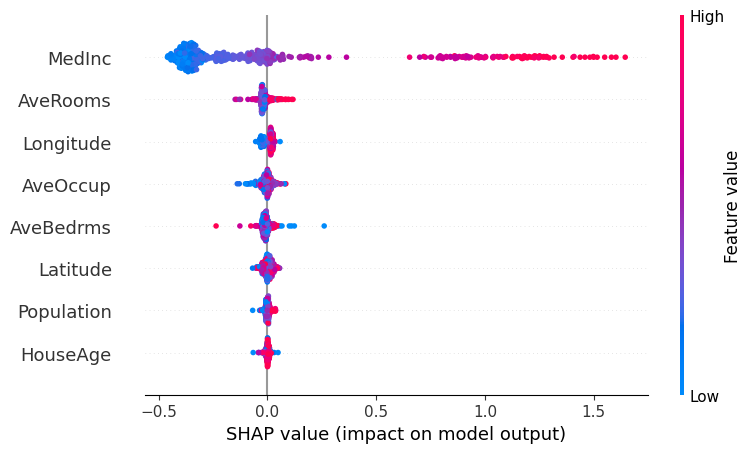

In [1]:
from geovisxrd.recursive.pipeline import run_recursive_step

# 手动启动第二层分析
path_layer2 = run_recursive_step(
    layer_num=2, 
    previous_shap_path="test_outputs/shap/xgb_data/shap_20260120_144656.joblib", 
    target_feature_name="MedInc"
)

--- [GeoVisXRD] 正在加载 SHAP 数据: test_outputs/layer_2_MedInc/shap_data/layer2_20260122_203118.joblib ...
--- [GeoVisXRD] 开始第 3 层分析: HouseAge ---
Save layer3_xgb_20260122_203425.pkl to test_outputs/layer_3_HouseAge/models/layer3_xgb_20260122_203425.pkl
--- [GeoVisXRD] 检测到模型类型: XGBRegressor ---
--- [GeoVisXRD] 正在使用 TreeExplainer (树模型专用)...
--- [GeoVisXRD] 正在计算 SHAP 值 (共 500 条数据)... ---


SHAP 计算进度: 100%|██████████| 1/1 [00:00<00:00, 113.91batch/s]

--- [GeoVisXRD] 计算完成，正在绘图... ---


--- [GeoVisXRD] 图片已保存至: test_outputs/layer_3_HouseAge/shap_summary.png ---
--- [GeoVisXRD] 完整数据(二进制)已保存至: test_outputs/layer_3_HouseAge/shap_data/layer3_20260122_203426.joblib
--- [GeoVisXRD] SHAP值表格(CSV)已保存至: test_outputs/layer_3_HouseAge/shap_data/csv_data/layer3_20260122_203426.csv
   [Model] SAM (Structural Agnostic Model)


100%|██████████| 1100/1100 [01:00<00:00, 18.13it/s, disc=3.09, gen=-0.285, regul_loss=0.44, tot=2.08]  


SAM Training finished.
📊 正在从已保存的模型中提取权重并进行动态阈值分割...
   - [t=0.2 vs 0.1] 稳定性: 1.0000
   - [t=0.3 vs 0.2] 稳定性: 1.0000
   - [t=0.4 vs 0.3] 稳定性: 0.2500
   - [t=0.5 vs 0.4] 稳定性: 0.0000
   - [t=0.6 vs 0.5] 稳定性: 1.0000
   - [t=0.7 vs 0.6] 稳定性: 1.0000
   - [t=0.8 vs 0.7] 稳定性: 1.0000
   - [t=0.9 vs 0.8] 稳定性: 1.0000
   - [t=1.0 vs 0.9] 稳定性: 1.0000
✅ 曲线图已生成: test_outputs/layer_3_HouseAge/stability_curve.png
🎨 正在绘制因果图 (Threshold=0.2)...
   - 图片已保存: test_outputs/layer_3_HouseAge/final_causal_graph.png
--- [GeoVisXRD] 第 3 层执行完毕。下一层路径: test_outputs/layer_3_HouseAge/shap_data/layer3_20260122_203426.joblib ---


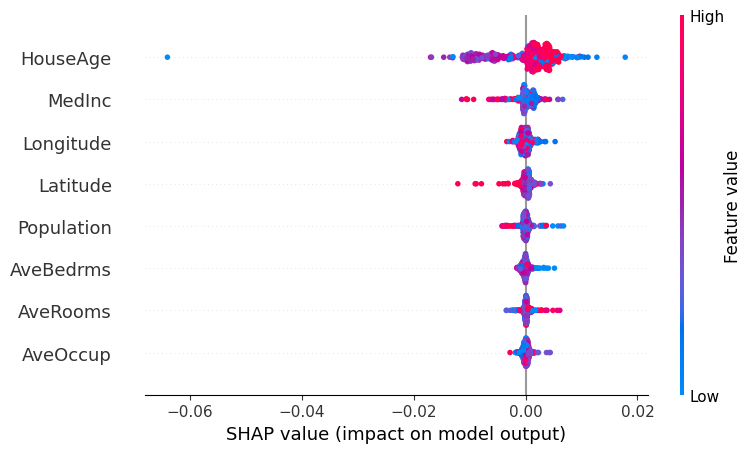

In [3]:
# 如果你发现 HouseAge 在驱动 MedInc 的贡献，则继续
path_layer3 = run_recursive_step(
    layer_num=3, 
    previous_shap_path=path_layer2, # 自动传入上一层刚生成的文件
    target_feature_name="HouseAge"
)